In [1]:
import numpy as np
from scipy.interpolate import *
from scipy.sparse.linalg import cg, LinearOperator
import matplotlib.pyplot as plt

In [2]:
def apply_stencil(u):
    i, j, k = u.shape
    result = np.zeros_like(u)
    result[1:-1, 1:-1, 1:-1] = (
        + 6*u[1:-1, 1:-1, 1:-1]
        - u[2:, 1:-1, 1:-1] - u[:-2, 1:-1, 1:-1]
        - u[1:-1, 2:, 1:-1] - u[1:-1, :-2, 1:-1]
        - u[1:-1, 1:-1, 2:] - u[1:-1, 1:-1, :-2]
        
    )
    return result

def compute_res(u, rhs):
    temp = apply_stencil(u)-rhs
    return np.sqrt(np.sum(temp*temp)/ temp.size)

def rb_gauss_seidel_3d(u, f, iterations=3):
    n, m, p = u.shape
    for _ in range(iterations):
        # Red update: (i + j + k) % 2 == 0
        for i in range(1, n - 1):
            for j in range(1, m - 1):
                for k in range(1, p - 1):
                    if (i + j + k) % 2 == 0:
                        u[i, j, k] = (1/6) * (
                            u[i+1, j, k] + u[i-1, j, k] +
                            u[i, j+1, k] + u[i, j-1, k] +
                            u[i, j, k+1] + u[i, j, k-1] +
                            f[i, j, k]
                        )
        # Black update: (i + j + k) % 2 == 1
        for i in range(1, n - 1):
            for j in range(1, m - 1):
                for k in range(1, p - 1):
                    if (i + j + k) % 2 == 1:
                        u[i, j, k] = (1/6) * (
                            u[i+1, j, k] + u[i-1, j, k] +
                            u[i, j+1, k] + u[i, j-1, k] +
                            u[i, j, k+1] + u[i, j, k-1] +
                            f[i, j, k]
                        )
    return u


def restrict(res):
    return res[::2, ::2, ::2]



def prolong_with_rgi(u_coarse):
    nx, ny, nz = u_coarse.shape

    # 1. Define the coarse grid coordinates
    x_coarse = np.linspace(0, 1, nx)
    y_coarse = np.linspace(0, 1, ny)
    z_coarse = np.linspace(0, 1, nz)

    # 2. Set up the interpolator
    interpolator = RegularGridInterpolator(
        (x_coarse, y_coarse, z_coarse),
        u_coarse,
        method='linear',
        bounds_error=False,
        fill_value=0.0  # Can also be 'nearest' or extrapolation value
    )

    # 3. Define the fine grid coordinates (twice as fine)
    nx_f, ny_f, nz_f = 2 * nx - 1, 2 * ny - 1, 2 * nz - 1
    x_fine = np.linspace(0, 1, nx_f)
    y_fine = np.linspace(0, 1, ny_f)
    z_fine = np.linspace(0, 1, nz_f)

    # 4. Create meshgrid and points to evaluate
    X, Y, Z = np.meshgrid(x_fine, y_fine, z_fine, indexing='ij')
    points = np.stack((X, Y, Z), axis=-1)  # shape (nx_f, ny_f, nz_f, 3)

    # 5. Interpolate
    u_fine = interpolator(points)  # returns shape (nx_f, ny_f, nz_f)

    return u_fine

In [3]:
def set_boundary_conditions(u):
    i, j, k = np.shape(u)
    for x in range(i):
        for y in range(j):
            u[x, y, k-1]=1
            u[x, y, 0]= 0

    for x in range(i):
        for z in range(k):
            u[x, j-1, z] = z / (k-1)
            u[x, 0, z] = z / (k-1)

    for y in range(j):
        for z in range(k):
            u[i-1, y, z] = z / (k-1)
            u[0, y, z] = z / (k-1)



shape=(3,3,3)

# Matrix-vector product for flattened input
def matvec_shape(x_flat, shape):
    x_grid = np.zeros([shape[0]+2,shape[1]+2,shape[2]+2])
    x_grid[1:-1, 1:-1, 1:-1] = x_flat.reshape(shape)
    Ax_grid = apply_stencil(x_grid) / 4  #We need to divide by 4 in order to account for different grid steps
    return Ax_grid[1:-1, 1:-1, 1:-1].ravel()

def get_matvec_shape(shape):
    return lambda x_flat: matvec_shape(x_flat, shape)

In [4]:
def multigrid_2_V_cycle(base_length, num_iters):
    level_1_length = 2*base_length+1
    level_2_length = 2*2*base_length+1

    #setting boundary conditions
    u = np.zeros(level_2_length)
    set_boundary_conditions(u)

    #print(u)

    #Allocating right hand side
    rhs = -apply_stencil(u)

    #Allocating working array
    guess = np.zeros(level_2_length)

    #getting matvec function and linear operator
    matvec = get_matvec_shape(level_1_length-2)
    n = (2*base_length[0]-1)*(2*base_length[1]-1)*(2*base_length[2]-1)
    A = LinearOperator((n, n), matvec=matvec)

    #Now doing the multigrid operation
    residuals=[]
    for i in range(num_iters):
        residuum = compute_res(guess, rhs)
        print("The residuum after ", i, " iterations is ", residuum)
        residuals.append(residuum)
        rb_gauss_seidel_3d(guess, rhs, iterations=2)
        #print("The guess after a ", 2, " Gauss-Seidel iteration is: ")
        #print(guess)
        #coarsening
        defect_domain = rhs-apply_stencil(guess)
        #print("The defect domain before coarsening is: ")
        #print(defect_domain)
        coarse = restrict(defect_domain)
        #print("The right hand side after coarsening is: ")
        #print(coarse)
        #unravel coarse
        unravel_c = coarse[1:-1, 1:-1, 1:-1].ravel()
        #solving coarse_grid
        sol = cg(A, unravel_c)[0]
        #print (sol)
        sol_shaped = sol.reshape(2*base_length-1)

        coarse[1:-1, 1:-1, 1:-1] = sol_shaped

        #print("The solution after the coarse grid solver is:")
        #print(coarse)

        

        #refining
        refinemend = prolong_with_rgi(coarse)

        #print("The refined coarse grid solution: ")
        #print(refinemend)

        #Adding correction
        #print (refinemend.shape)
        guess[1:-1, 1:-1, 1:-1]+=refinemend[1:-1, 1:-1, 1:-1]

        #print("After adding the coarse grid correction the guess is:")
        #print(guess)

        

        #doing the post smoothing
        rb_gauss_seidel_3d(guess, rhs, iterations=2)

    #print("After the post smoothing step the guess is:")
    #print(guess)

    guess+=u


    return guess, residuals

In [5]:
#Tomorrow still need to see where the problems occur
np.set_printoptions(precision=3)
base_length = np.array([20,20,20])
guess, residuals = multigrid_2_V_cycle(base_length, 10)

#print(guess)

xs= np.linspace(0, 10, 1)

The residuum after  0  iterations is  0.16991768495290682
The residuum after  1  iterations is  0.053582069533342026
The residuum after  2  iterations is  0.03441186342384763
The residuum after  3  iterations is  0.02587256705566426
The residuum after  4  iterations is  0.020972854301984006
The residuum after  5  iterations is  0.017766691354862182
The residuum after  6  iterations is  0.015489317077443379
The residuum after  7  iterations is  0.01377921068647529
The residuum after  8  iterations is  0.012442578700325826
The residuum after  9  iterations is  0.011365789495651289


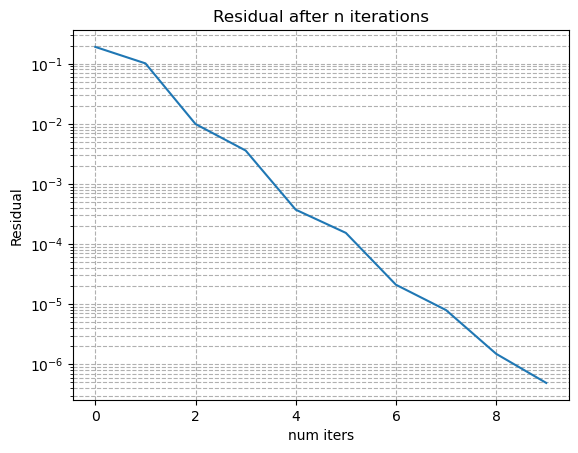

In [56]:
xs= np.linspace(0, 9, 10)
plt.xlabel("num iters")
plt.ylabel("Residual")
plt.title("Residual after n iterations")
plt.yscale("log")
plt.grid(True, which="both", linestyle='--')
plt.plot(xs, residuals)
plt.savefig("Residual_plot.pdf",format="pdf")


In [185]:
shape=(3,3,3)

matvec = get_matvec_shape(shape)

u=np.zeros([5,5,5])
set_boundary_conditions(u)
#u_fine = prolong_with_rgi(u)

#print(u)
#print (u_fine)

rhs = apply_stencil(u)

#print(rhs)
#print(u)

n = 3*3*3
A = LinearOperator((n, n), matvec=matvec)

unraveled = rhs[1:-1, 1:-1, 1:-1].ravel()

sol = cg(A, unraveled)
u[1:-1, 1:-1, 1:-1]+=sol[0].reshape(shape)

print(u)

[[[ 0.    0.25  0.5   0.75  1.  ]
  [ 0.    0.25  0.5   0.75  1.  ]
  [ 0.    0.25  0.5   0.75  1.  ]
  [ 0.    0.25  0.5   0.75  1.  ]
  [ 0.    0.25  0.5   0.75  1.  ]]

 [[ 0.    0.25  0.5   0.75  1.  ]
  [ 0.   -2.   -4.   -6.    1.  ]
  [ 0.   -2.   -4.   -6.    1.  ]
  [ 0.   -2.   -4.   -6.    1.  ]
  [ 0.    0.25  0.5   0.75  1.  ]]

 [[ 0.    0.25  0.5   0.75  1.  ]
  [ 0.   -2.   -4.   -6.    1.  ]
  [ 0.   -2.   -4.   -6.    1.  ]
  [ 0.   -2.   -4.   -6.    1.  ]
  [ 0.    0.25  0.5   0.75  1.  ]]

 [[ 0.    0.25  0.5   0.75  1.  ]
  [ 0.   -2.   -4.   -6.    1.  ]
  [ 0.   -2.   -4.   -6.    1.  ]
  [ 0.   -2.   -4.   -6.    1.  ]
  [ 0.    0.25  0.5   0.75  1.  ]]

 [[ 0.    0.25  0.5   0.75  1.  ]
  [ 0.    0.25  0.5   0.75  1.  ]
  [ 0.    0.25  0.5   0.75  1.  ]
  [ 0.    0.25  0.5   0.75  1.  ]
  [ 0.    0.25  0.5   0.75  1.  ]]]
